## Regime-Aware Sector Rotation Model

This notebook builds a regime-aware sector rotation model using 25 years of S&P 500 data to answer a practical question: **which sectors should you rotate into given current market conditions?**

The core hypothesis is that sector performance is not random — it depends on the broader market environment. By classifying the market into distinct regimes and measuring historical sector returns within each, we can make informed, data-driven rotation decisions.

### What it does

1. **Setup** — imports all required libraries and initializes the environment.

2. **Data loading & preparation** — loads S&P 500 stock price history alongside company metadata (sector, industry, exchange). Stocks are merged with their sector labels and sorted chronologically per symbol.

3. **Feature engineering** — computes a rich set of per-stock technical indicators:
   - Multi-horizon returns: 1-day, 5-day, 21-day, 63-day
   - Simple moving averages: SMA-10, SMA-21, SMA-50, SMA-200
   - Price-to-SMA ratios (50-day and 200-day)
   - Momentum: 21-day and 63-day
   - Volatility: rolling 21-day and 63-day standard deviation of daily returns
   - Volume ratio: current volume vs. 21-day average
   - Forward returns: 5-day, 21-day, and 63-day (used as prediction targets)

4. **Market-level aggregation** — collapses stock-level data into a single daily market table by averaging key metrics across all constituents, including breadth indicators that measure how broadly a market move is distributed across stocks rather than concentrated in a handful of large-caps.

5. **Regime classification** — labels each trading day with two independent regimes:
   - **Trend regime** (bull / sideways / bear): based on the 63-day average market return — above +8% is bull, below -8% is bear, otherwise sideways
   - **Volatility regime** (low / normal / high): based on 21-day average volatility relative to its historical 25th and 75th percentiles
   - These combine into **9 possible regimes** (e.g., `bull_low_vol`, `bear_high_vol`)

6. **Regime validation** — validates the volatility regime labels against the CBOE VIX, the market's independently established fear index. Average VIX is computed per regime alongside mean absolute deviation and percentage deviation, confirming that days labeled `high_vol` correspond to meaningfully higher VIX readings than `normal_vol` or `low_vol` days.

7. **Regime timeline visualization** — overlays classified regimes as colored bands on a cumulative market index chart, with a zoom into the 2008 financial crisis as a representative example of the classifier capturing real market conditions.

8. **Sector performance by regime** — for each of the 9 regimes, computes per-sector statistics across all historical observations: average and median 21-day and 63-day forward returns, hit rate (% of positive outcomes), standard deviation, and a Sharpe-like return-to-risk ratio. Results are visualized as a heatmap.

9. **Current regime & recommendation** — detects the most recent market regime and surfaces the top historically strongest sectors for that regime, with expected 21-day return, hit rate, and Sharpe-like ratio.

10. **Backtesting** — simulates a monthly rebalancing strategy that rotates into the top N historically strongest sectors for the current regime, using only data available at each point in time to prevent look-ahead bias. Key features:
    - **Configurable sector count** — `get_backtest_df_per_n_top_sectors(n)` lets you test how performance changes as you vary the number of sectors held, exploring the concentration vs. diversification tradeoff
    - **Windowed analysis** — `plot_backtest_window(results_df, start, end)` lets you zoom into any date range with automatically rebased growth curves and recomputed metrics, making it easy to isolate performance during specific market events like the 2008 financial crisis or COVID-19
    - **Performance metrics** — cumulative return, annualized Sharpe ratio, and maximum drawdown reported for both strategy and equal-weight benchmark

### Data
Two CSV files: `sp500_stocks.csv` (daily OHLCV price data) and `sp500_companies.csv` (company metadata including sector and date added to the index).

### Stack
Python 3 · pandas · NumPy · Matplotlib · Seaborn · yfinance

## 1. Setup

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # data visualization
import matplotlib.pyplot as plt # plotting
import yfinance as yf # to fetch financial data
import kaggle
import os

## 2. Data Loading

In [3]:
# Load CSV files

kaggle.api.authenticate()
DATASET_SLUG = 'darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily'
DOWNLOAD_DIR = 'data/raw'

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

kaggle.api.dataset_download_files(
    DATASET_SLUG,
    path=DOWNLOAD_DIR,
    unzip=True,
    quiet=False
)

print(f"Dataset downloaded to {DOWNLOAD_DIR}/")
print(os.listdir(DOWNLOAD_DIR))


stocks = pd.read_csv('data/raw/sp500_stocks.csv')
companies = pd.read_csv('data/raw/sp500_companies.csv')



print(stocks.head())
print(companies.head())

Dataset URL: https://www.kaggle.com/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily


100%|██████████| 99.4M/99.4M [00:04<00:00, 25.9MB/s]



Dataset downloaded to data/raw/
['sp500_stocks.csv', '.DS_Store', 'sp500_companies.csv']
         date       open       high        low      close     volume symbol
0  2000-01-03  46.963915  47.075734  40.180238  42.938438  4674353.0      A
1  2000-01-04  40.627500  41.074778  38.614762  39.658405  4765083.0      A
2  2000-01-05  39.509288  39.658382  35.968364  37.198368  5758642.0      A
3  2000-01-06  36.751110  36.974749  34.663825  35.782013  2534434.0      A
4  2000-01-07  35.222933  39.322957  35.185662  38.763863  2819626.0      A
  symbol              company                  sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                     sub_industry             headquarters  date_added  \
0        Industrial Conglomerates    

In [4]:
# Inspect data
print(stocks.info())
print(companies.info())

# Fix data types
stocks['date'] = pd.to_datetime(stocks['date'])
companies['date_added'] = pd.to_datetime(companies['date_added'], errors='coerce')

print(stocks['date'].dtype)
print(companies['date_added'].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2911994 entries, 0 to 2911993
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   date    object 
 1   open    float64
 2   high    float64
 3   low     float64
 4   close   float64
 5   volume  float64
 6   symbol  object 
dtypes: float64(5), object(2)
memory usage: 155.5+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   symbol        503 non-null    object
 1   company       503 non-null    object
 2   sector        503 non-null    object
 3   sub_industry  503 non-null    object
 4   headquarters  503 non-null    object
 5   date_added    503 non-null    object
 6   founded       503 non-null    object
dtypes: object(7)
memory usage: 27.6+ KB
None
datetime64[ns]
datetime64[ns]


In [5]:
# Merge stock data with company info and sort
merged = stocks.merge(companies, on='symbol', how='left')
merged = merged.sort_values(['symbol', 'date']).reset_index(drop=True)
merged[['date', 'symbol', 'close', 'sector']].head(10)

,date,symbol,close,sector
0,2000-01-03,A,42.938438,Health Care
1,2000-01-04,A,39.658405,Health Care
2,2000-01-05,A,37.198368,Health Care
3,2000-01-06,A,35.782013,Health Care
4,2000-01-07,A,38.763863,Health Care
5,2000-01-10,A,41.112045,Health Care
6,2000-01-11,A,40.552937,Health Care
7,2000-01-12,A,39.732964,Health Care
8,2000-01-13,A,40.329308,Health Care
9,2000-01-14,A,40.776596,Health Care


## 3. Feature Engineering

In [6]:
# Calculate (1d, 5d, 21d, 63d) returns
merged['ret_1d'] = merged.groupby('symbol')['close'].pct_change(1)
merged['ret_5d'] = merged.groupby('symbol')['close'].pct_change(5)
merged['ret_21d'] = merged.groupby('symbol')['close'].pct_change(21)
merged['ret_63d'] = merged.groupby('symbol')['close'].pct_change(63)

merged[["date", "symbol", "close", "ret_1d", "ret_21d"]].head(15)

,date,symbol,close,ret_1d,ret_21d
0,2000-01-03,A,42.938438,NaN,NaN
1,2000-01-04,A,39.658405,-0.076389,NaN
2,2000-01-05,A,37.198368,-0.062031,NaN
3,2000-01-06,A,35.782013,-0.038076,NaN
4,2000-01-07,A,38.763863,0.083334,NaN
5,2000-01-10,A,41.112045,0.060577,NaN
6,2000-01-11,A,40.552937,-0.013600,NaN
7,2000-01-12,A,39.732964,-0.020220,NaN
8,2000-01-13,A,40.329308,0.015009,NaN
9,2000-01-14,A,40.776596,0.011091,NaN


In [7]:
# Calculate moving averages
merged["sma_10"]  = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(10).mean())
merged["sma_21"]  = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(21).mean())
merged["sma_50"]  = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(50).mean())
merged["sma_200"] = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(200).mean())

# Calculate price relative to moving average
merged["price_to_sma_50"]  = merged["close"] / merged["sma_50"]
merged["price_to_sma_200"] = merged["close"] / merged["sma_200"]

In [8]:
# Calculate momentum
merged["momentum_21d"] = merged.groupby("symbol")["close"].transform(lambda x: x / x.shift(21) - 1)
merged["momentum_63d"] = merged.groupby("symbol")["close"].transform(lambda x: x / x.shift(63) - 1)

# Calculate volatility
merged["volatility_21d"] = merged.groupby("symbol")["ret_1d"].transform(lambda x: x.rolling(21).std())
merged["volatility_63d"] = merged.groupby("symbol")["ret_1d"].transform(lambda x: x.rolling(63).std())

# Calculate rolling average volume and volume ratio
merged["avg_volume_21d"]   = merged.groupby("symbol")["volume"].transform(lambda x: x.rolling(21).mean())
merged["volume_ratio_21d"] = merged["volume"] / merged["avg_volume_21d"]

In [9]:
# Calculate forward returns

merged["fwd_ret_5d"] = merged.groupby("symbol")["close"].transform(lambda x: x.shift(-5) / x - 1)
merged["fwd_ret_21d"] = merged.groupby("symbol")["close"].transform(lambda x: x.shift(-21) / x - 1)
merged["fwd_ret_63d"] = merged.groupby("symbol")["close"].transform(lambda x: x.shift(-63) / x - 1)

merged.head()

,date,open,high,low,close,volume,symbol,company,sector,sub_industry,...,price_to_sma_200,momentum_21d,momentum_63d,volatility_21d,volatility_63d,avg_volume_21d,volume_ratio_21d,fwd_ret_5d,fwd_ret_21d,fwd_ret_63d
0,2000-01-03,46.963915,47.075734,40.180238,42.938438,4674353.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.042535,0.062500,0.361111
1,2000-01-04,40.627500,41.074778,38.614762,39.658405,4765083.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022556,0.169173,0.406015
2,2000-01-05,39.509288,39.658382,35.968364,37.198368,5758642.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.068137,0.222445,0.554109
3,2000-01-06,36.751110,36.974749,34.663825,35.782013,2534434.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127083,0.325000,0.750000
4,2000-01-07,35.222933,39.322957,35.185662,38.763863,2819626.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.051923,0.215384,0.876923


In [10]:
# Inspect missing values

merged[[
    "ret_1d", "ret_21d", "sma_50", "sma_200",
    "momentum_21d", "volatility_21d", "fwd_ret_21d"
]].isna().sum()

ret_1d               503
ret_21d            10563
sma_50             24647
sma_200           100007
momentum_21d       10563
volatility_21d     10563
fwd_ret_21d        10563
dtype: int64

## 4. Market-Level Aggregation

In [11]:
# Build market-level table
market = (
    merged.groupby("date")
      .agg(
          market_ret_1d=        ("ret_1d",         "mean"),
          market_ret_5d=        ("ret_5d",         "mean"),
          market_ret_21d=       ("ret_21d",        "mean"),
          market_ret_63d=       ("ret_63d",        "mean"),
          market_volatility_21d=("volatility_21d", "mean"),
          market_volatility_63d=("volatility_63d", "mean"),
          breadth_pct_positive_1d=("ret_1d", lambda x: (x > 0).mean()),
          avg_volume_ratio=     ("volume_ratio_21d", "mean")
      )
      .reset_index()
)

# Add breadth above moving averages
breadth = (
    merged.assign(
        above_sma50=merged["close"]  > merged["sma_50"],
        above_sma200=merged["close"] > merged["sma_200"]
    )
    .groupby("date")
    .agg(
        breadth_pct_above_sma50= ("above_sma50",  "mean"),
        breadth_pct_above_sma200=("above_sma200", "mean")
    )
    .reset_index()
)

market = market.merge(breadth, on="date", how="left")
market.head()

,date,market_ret_1d,market_ret_5d,market_ret_21d,market_ret_63d,market_volatility_21d,market_volatility_63d,breadth_pct_positive_1d,avg_volume_ratio,breadth_pct_above_sma50,breadth_pct_above_sma200
0,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.0,0.0
1,2000-01-04,-0.025896,NaN,NaN,NaN,NaN,NaN,0.131805,NaN,0.0,0.0
2,2000-01-05,0.008296,NaN,NaN,NaN,NaN,NaN,0.578797,NaN,0.0,0.0
3,2000-01-06,0.004777,NaN,NaN,NaN,NaN,NaN,0.567335,NaN,0.0,0.0
4,2000-01-07,0.027303,NaN,NaN,NaN,NaN,NaN,0.770774,NaN,0.0,0.0


## 5. Regime Classification

In [12]:
# Define and apply trend regime (Bull / Sideways / Bear)
def classify_trend(ret_63d):
    '''
    Labels the market based on 63-day return:
    above +8%  → bull
    below -8%  → bear
    otherwise  → sideways
    '''
    if pd.isna(ret_63d):
        return np.nan
    elif ret_63d > 0.08:
        return "bull"
    elif ret_63d < -0.08:
        return "bear"
    else:
        return "sideways"

market["trend_regime"] = market["market_ret_63d"].apply(classify_trend)

# Define and apply volatility regime (low / normal / high)
vol_25 = market["market_volatility_21d"].quantile(0.25)
vol_75 = market["market_volatility_21d"].quantile(0.75)

def classify_vol(vol):
    '''
    above 75th percentile → high_vol
    below 25th percentile → low_vol
    otherwise             → normal_vol
    '''
    if pd.isna(vol):
        return np.nan
    elif vol > vol_75:
        return "high_vol"
    elif vol < vol_25:
        return "low_vol"
    else:
        return "normal_vol"

market["vol_regime"] = market["market_volatility_21d"].apply(classify_vol)

# Create combined regime
market["combined_regime"] = market["trend_regime"] + "_" + market["vol_regime"]
market[63:69]

,date,market_ret_1d,market_ret_5d,market_ret_21d,market_ret_63d,market_volatility_21d,market_volatility_63d,breadth_pct_positive_1d,avg_volume_ratio,breadth_pct_above_sma50,breadth_pct_above_sma200,trend_regime,vol_regime,combined_regime
63,2000-04-03,-0.006412,0.007213,0.077762,0.072094,0.041995,0.037596,0.495726,0.946313,0.726496,0.0,sideways,high_vol,sideways_high_vol
64,2000-04-04,-0.004664,0.008254,0.083950,0.091969,0.041497,0.037635,0.424501,1.253018,0.729345,0.0,bull,high_vol,bull_high_vol
65,2000-04-05,0.007103,0.013794,0.113153,0.093426,0.040561,0.037639,0.508523,0.995130,0.741477,0.0,bull,high_vol,bull_high_vol
66,2000-04-06,0.013092,0.021352,0.120243,0.106330,0.040593,0.037556,0.599432,0.838173,0.767045,0.0,bull,high_vol,bull_high_vol
67,2000-04-07,0.004081,0.010810,0.103605,0.083461,0.040629,0.037378,0.440341,0.782540,0.750000,0.0,bull,high_vol,bull_high_vol
68,2000-04-10,-0.009274,0.008518,0.099447,0.056127,0.040671,0.037375,0.460227,0.800208,0.735795,0.0,sideways,high_vol,sideways_high_vol


## 6. VIX Validation

In [13]:
from datetime import datetime

vix = yf.Ticker('^VIX').history(start=stocks['date'].min(), end= datetime.today()).reset_index('Date')
vix['Date'] = pd.to_datetime(vix['Date']).dt.tz_localize(None)
vix.rename(columns={'Close': 'vix', 'Date': 'date'}, inplace=True)

market_vix = market.merge(vix, left_on='date', right_on='date', how='left')[['date', 'combined_regime', 'vix']]
market_vix = market_vix.dropna(subset=['combined_regime']).copy() # drop rows where combined_regime is missing

market_vix['avg_vix'] = market_vix.groupby('combined_regime')['vix'].transform('mean').round(2)

# Deviation between actual VIX on that day and the average VIX for its regime
market_vix['vix_deviation'] = market_vix['vix'] - market_vix['avg_vix']
market_vix['vix_abs_deviation'] = market_vix['vix_deviation'].abs()
# Percentage deviation — how far off relative to the regime average
market_vix['vix_pct_deviation'] = (market_vix['vix_deviation'] / market_vix['avg_vix']) * 100

validation_summary = (
    market_vix.groupby('combined_regime')
    .agg(
        avg_vix              = ('vix',               'mean'), # confirms the regime ordering makes sense
        avg_abs_deviation    = ('vix_abs_deviation',  'mean'), # on average, how many VIX points off is a given label
        avg_pct_deviation    = ('vix_pct_deviation',  'mean'), # avg_abs_deviation as %
        max_abs_deviation    = ('vix_abs_deviation',  'max'), # worst case mislabel -- high number = wrong matches
        std_vix              = ('vix',               'std'), # how spread out the VIX readings are within each regime
        obs                  = ('vix',               'count')
    )
    .round(2)
    .sort_values('avg_vix', ascending=False)
)


validation_summary

,avg_vix,avg_abs_deviation,avg_pct_deviation,max_abs_deviation,std_vix,obs
combined_regime,,,,,,
bear_high_vol,39.97,10.13,-0.01,42.72,12.99,376
sideways_high_vol,26.59,4.60,-0.00,26.03,6.05,890
bear_normal_vol,25.92,3.94,-0.00,10.15,4.70,60
bull_high_vol,25.11,3.96,-0.01,20.38,5.00,337
sideways_normal_vol,18.16,3.55,-0.02,22.58,4.58,2158
bull_normal_vol,17.99,3.41,-0.02,22.96,4.20,1073
sideways_low_vol,13.69,2.04,-0.01,12.02,2.58,1075
bull_low_vol,13.43,1.84,-0.02,8.25,2.29,570


### Regime Validation

Before building on top of these regime labels, we validate them against 
the CBOE VIX — the market's independently established volatility benchmark. 
If our classifier is working correctly, days labeled `high_vol` should 
correspond to meaningfully higher VIX readings than `normal_vol` or `low_vol` 
days. A low average deviation between actual VIX and regime-average VIX 
confirms the labels are capturing real market conditions, not noise.

## 7. Regime Visualization

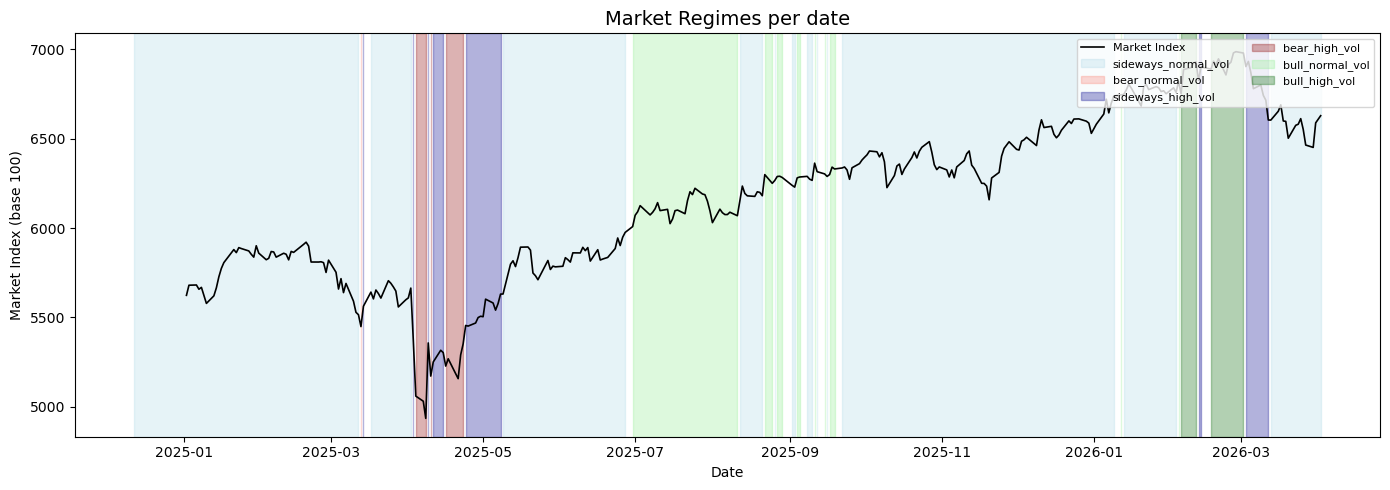

In [14]:
# Regime timeline chart
market["market_index"] = 100 * (1 + market["market_ret_1d"]).cumprod()

plot_df = market[["date", "market_index", "combined_regime"]].dropna().sort_values("date").reset_index(drop=True)

plot_df['changed']    = plot_df['combined_regime'].ne(plot_df['combined_regime'].shift())
plot_df['segment_id'] = plot_df['changed'].cumsum()
plot_df['start_date'] = plot_df.groupby('segment_id')['date'].transform('first')
plot_df['end_date']   = plot_df.groupby('segment_id')['date'].transform('last')

segments = plot_df.drop_duplicates('segment_id')[['segment_id', 'combined_regime', 'start_date', 'end_date']]

colors = {
    'bull_low_vol':       'green',
    'bull_normal_vol':    'lightgreen',
    'bull_high_vol':      'darkgreen',
    'bear_low_vol':       'red',
    'bear_normal_vol':    'salmon',
    'bear_high_vol':      'darkred',
    'sideways_low_vol':   'blue',
    'sideways_normal_vol':'lightblue',
    'sideways_high_vol':  'darkblue'
}

# Filter to 2008 for a focused view
zoom_start = pd.to_datetime('2025-01-01')
zoom_end   = pd.to_datetime('2026-12-31')
zoom_df    = plot_df[(plot_df['date'] >= zoom_start) & (plot_df['date'] <= zoom_end)]
zoom_segments = segments[
    (segments.start_date <= zoom_end) &
    (segments.end_date   >= zoom_start)
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom_df['date'], zoom_df['market_index'], color='black', linewidth=1.2, label='Market Index')

seen_regimes = set()
for _, segment in zoom_segments.iterrows():
    regime = segment['combined_regime']
    color  = colors.get(regime, 'gray')
    label  = regime if regime not in seen_regimes else None
    ax.axvspan(segment['start_date'], segment['end_date'], color=color, alpha=0.3, label=label)
    seen_regimes.add(regime)

ax.set_title('Market Regimes per date', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Market Index (base 100)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 8. Sector Performance by Regime

In [15]:
# Merge market table to stock_level data

df = merged.merge(
    market[["date", "trend_regime", "vol_regime", "combined_regime"]],
    on="date",
    how="left"
)

df[63:69]

,date,open,high,low,close,volume,symbol,company,sector,sub_industry,...,volatility_21d,volatility_63d,avg_volume_21d,volume_ratio_21d,fwd_ret_5d,fwd_ret_21d,fwd_ret_63d,trend_regime,vol_regime,combined_regime
63,2000-04-03,61.425809,61.574900,54.716679,58.443974,2030875.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.118649,0.079274,2.679454e+06,0.757944,0.093112,-0.066326,-0.248087,sideways,high_vol,sideways_high_vol
64,2000-04-04,58.443957,61.053063,48.902088,55.760303,3519884.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.049399,0.078845,2.575948e+06,1.366442,0.079546,-0.034759,-0.248663,bull,high_vol,bull_high_vol
65,2000-04-05,55.313024,59.562137,53.747559,57.810307,2109163.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.047210,0.078410,2.309203e+06,0.913373,-0.112830,-0.056737,-0.286912,bull,high_vol,bull_high_vol
66,2000-04-06,58.667598,62.618530,57.884865,62.618530,1375073.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.048456,0.078708,2.186399e+06,0.628921,-0.142857,-0.192857,-0.357143,bull,high_vol,bull_high_vol
67,2000-04-07,64.109444,74.545866,63.848537,72.756767,2975224.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.062070,0.080466,2.208334e+06,1.347271,-0.322234,-0.342725,-0.438524,bull,high_vol,bull_high_vol
68,2000-04-10,72.756745,72.756745,62.842146,63.885792,2956071.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.065474,0.081989,2.231035e+06,1.324977,-0.257876,-0.281213,-0.371645,sideways,high_vol,sideways_high_vol


In [16]:
# Calculate sector-relative performance

sector_perf = (
    df.groupby(["combined_regime", "sector"])
      .agg(
          avg_fwd_ret_21d=("fwd_ret_21d", "mean"),
          median_fwd_ret_21d=("fwd_ret_21d", "median"),
          avg_fwd_ret_63d=("fwd_ret_63d", "mean"),
          obs=("symbol", "count"),
          hit_rate = (("fwd_ret_21d", lambda x: (x > 0).mean())),
          std_fwd_ret_21d=("fwd_ret_21d", "std")
      )
      .reset_index()
      .sort_values(["combined_regime", "avg_fwd_ret_21d"], ascending=[True, False])
)

# Calculate a Sharpe-like ratio for each sector and regime
sector_perf['sharpe_like'] = sector_perf['avg_fwd_ret_21d'] / sector_perf['std_fwd_ret_21d']

# View top sectors for a regime
sector_perf[sector_perf["combined_regime"] == "bull_low_vol"].head(20)

,combined_regime,sector,avg_fwd_ret_21d,median_fwd_ret_21d,avg_fwd_ret_63d,obs,hit_rate,std_fwd_ret_21d,sharpe_like
33,bull_low_vol,Communication Services,0.015616,0.011063,0.032765,10447,0.568871,0.086335,0.180876
37,bull_low_vol,Financials,0.010824,0.012157,0.013103,39151,0.585298,0.061824,0.175073
35,bull_low_vol,Consumer Staples,0.010229,0.009985,0.023980,18652,0.579991,0.057017,0.179408
34,bull_low_vol,Consumer Discretionary,0.010126,0.009424,0.017898,24425,0.555046,0.082818,0.122274
39,bull_low_vol,Industrials,0.009966,0.009351,0.020689,39225,0.559873,0.069509,0.143384
38,bull_low_vol,Health Care,0.009792,0.008301,0.031269,30933,0.553325,0.074229,0.131910
40,bull_low_vol,Information Technology,0.008788,0.008415,0.023198,34250,0.544876,0.092282,0.095233
43,bull_low_vol,Utilities,0.008740,0.009415,0.023055,16592,0.586789,0.050879,0.171771
42,bull_low_vol,Real Estate,0.005809,0.007342,0.009474,16780,0.549702,0.059087,0.098317
41,bull_low_vol,Materials,0.005495,0.005955,0.013077,13276,0.537361,0.072937,0.075335


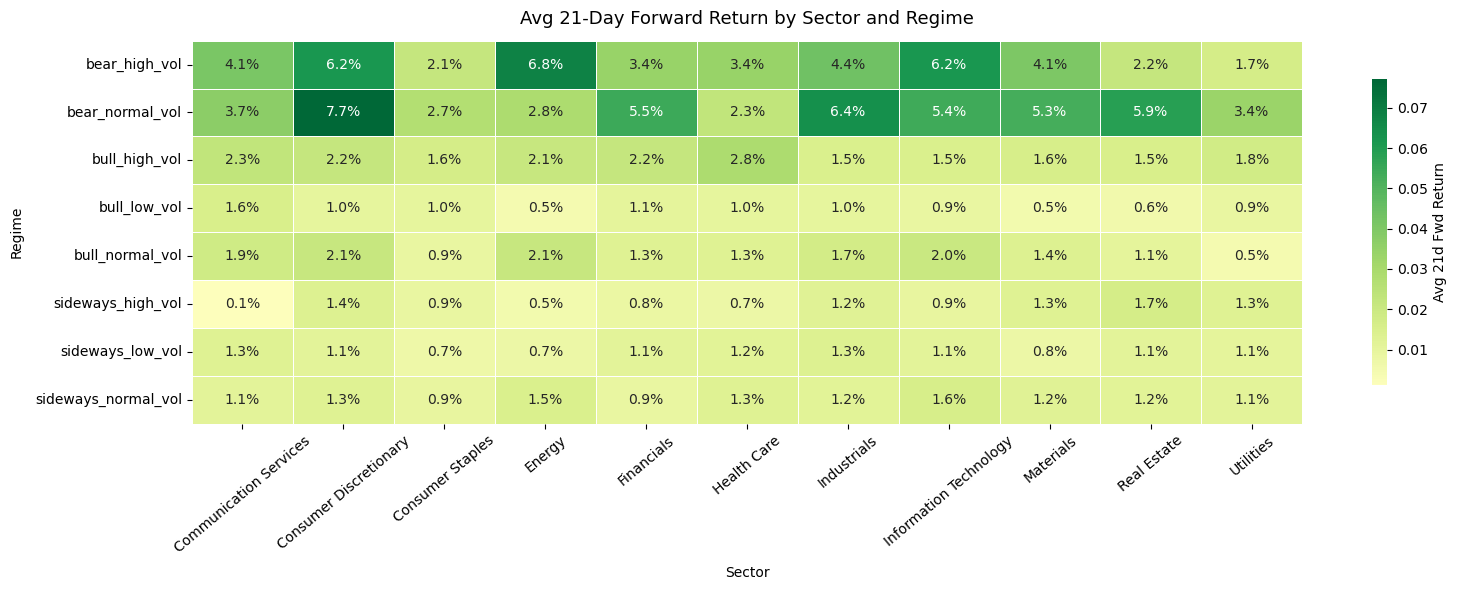

In [17]:
# Visualize average 21-day forward return by sector and regime
data = sector_perf.pivot(
    index="combined_regime",
    columns="sector",
    values="avg_fwd_ret_21d"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    data=data,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Avg 21d Fwd Return", "shrink": 0.8}
)
ax.set_title("Avg 21-Day Forward Return by Sector and Regime", fontsize=13, pad=12)
ax.set_xlabel("Sector", labelpad=8)
ax.set_ylabel("Regime", labelpad=8)
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 9. Current Regime Recommendation

In [18]:
# Get top sectors in each regime

def get_top_sectors_for_regime(regime, top_n=3):
    '''
    Given a regime like "bear_high_vol", it returns the best sectors historically.
    '''
    
    result = (
        sector_perf[sector_perf["combined_regime"] == regime]
        .sort_values("avg_fwd_ret_21d", ascending=False)
        .head(top_n)
    )
    return result[["sector", "avg_fwd_ret_21d", "avg_fwd_ret_63d", "obs", "hit_rate"]]

get_top_sectors_for_regime('sideways_normal_vol', 5)

,sector,avg_fwd_ret_21d,avg_fwd_ret_63d,obs,hit_rate
84,Information Technology,0.015938,0.054245,133613,0.568066
80,Energy,0.014569,0.058382,42177,0.572824
78,Consumer Discretionary,0.013118,0.048189,93345,0.563983
82,Health Care,0.012692,0.037529,118320,0.578043
85,Materials,0.012218,0.040150,51096,0.572393


In [19]:
# Get the current regime
latest_market  = market.dropna(subset=["combined_regime"]).sort_values("date").iloc[-1]
current_regime = latest_market["combined_regime"]

# Get top sectors for the current regime
top_sectors = get_top_sectors_for_regime(current_regime, top_n=3)

if not top_sectors.empty:
    print(f'Current regime: {current_regime}')
    print()
    print('Historically strongest sectors:')
    for _, row in top_sectors.iterrows():
        print(
            f"  - {row['sector']} "
            f"({row['avg_fwd_ret_21d']:+.2%} avg 21d return, "
            f"{row['hit_rate']:.2%} hit rate)"
        )

Current regime: sideways_normal_vol

Historically strongest sectors:
  - Information Technology (+1.59% avg 21d return, 56.81% hit rate)
  - Energy (+1.46% avg 21d return, 57.28% hit rate)
  - Consumer Discretionary (+1.31% avg 21d return, 56.40% hit rate)


## 10. Backtesting

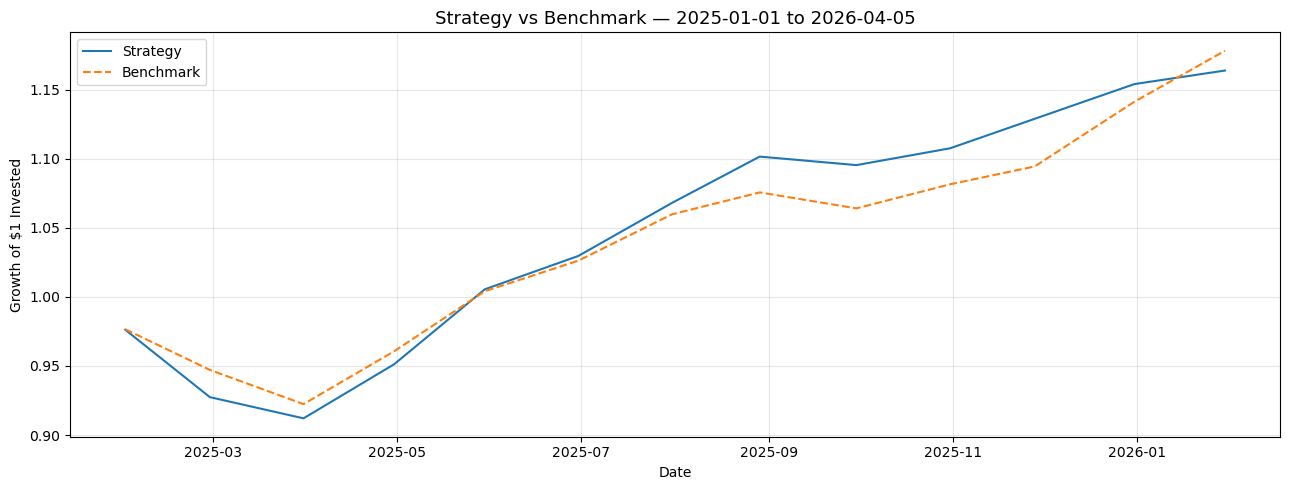

Period: 2025-01-01 → 2026-04-05

Metric                        Strategy    Benchmark
--------------------------------------------------
Cumulative Return               16.40%       17.84%
Sharpe Ratio                    1.4191       1.6606
Max Drawdown                    -6.57%       -5.55%


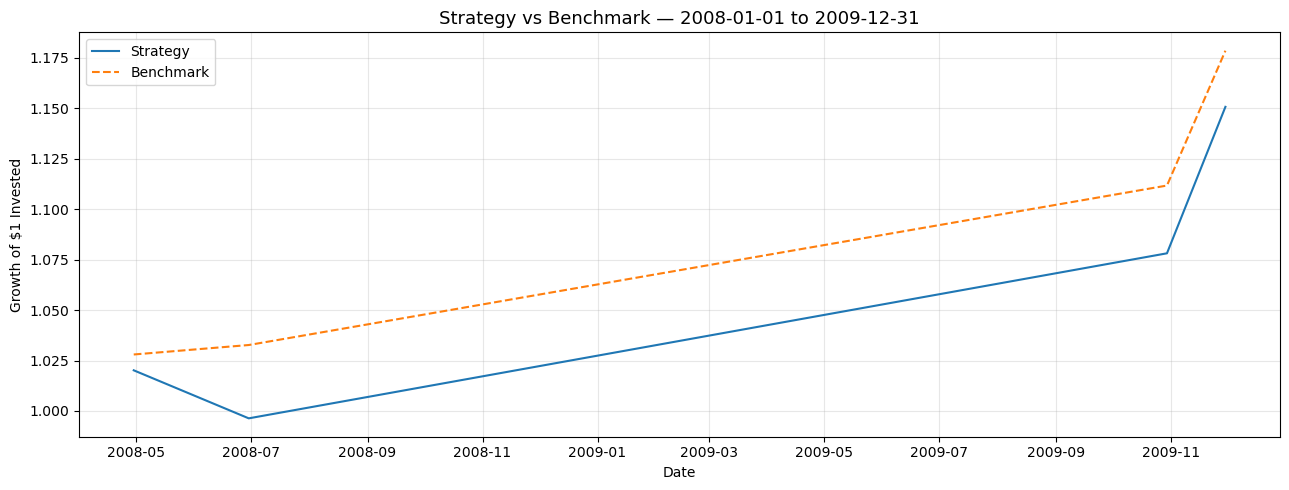

Period: 2008-01-01 → 2009-12-31

Metric                        Strategy    Benchmark
--------------------------------------------------
Cumulative Return               15.07%       17.85%
Sharpe Ratio                    2.6453       4.5453
Max Drawdown                    -2.33%        0.00%


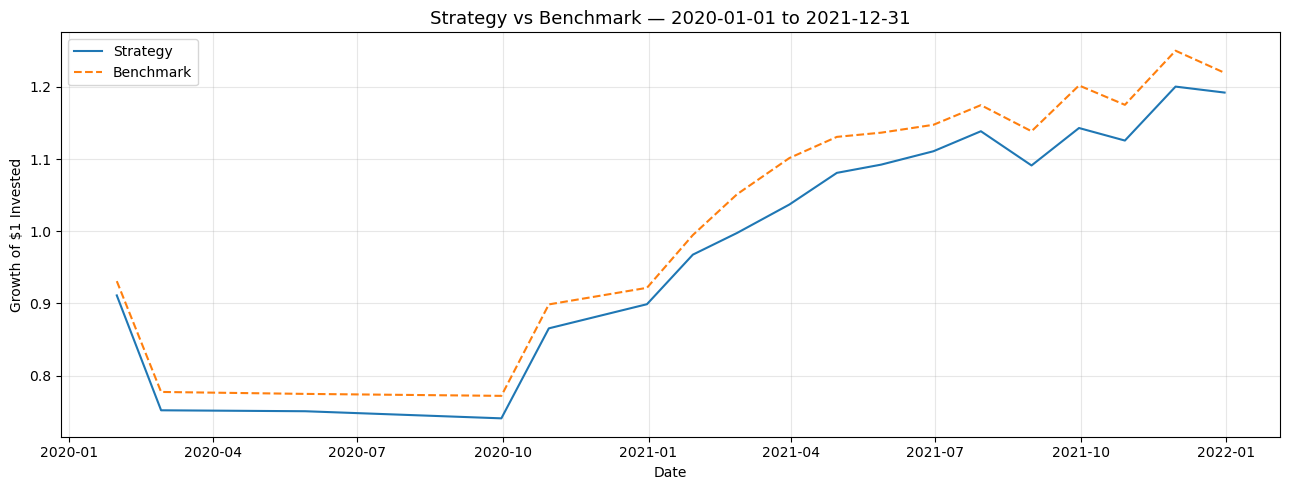

Period: 2020-01-01 → 2021-12-31

Metric                        Strategy    Benchmark
--------------------------------------------------
Cumulative Return               19.20%       21.93%
Sharpe Ratio                    0.5979       0.6770
Max Drawdown                   -18.68%      -17.06%


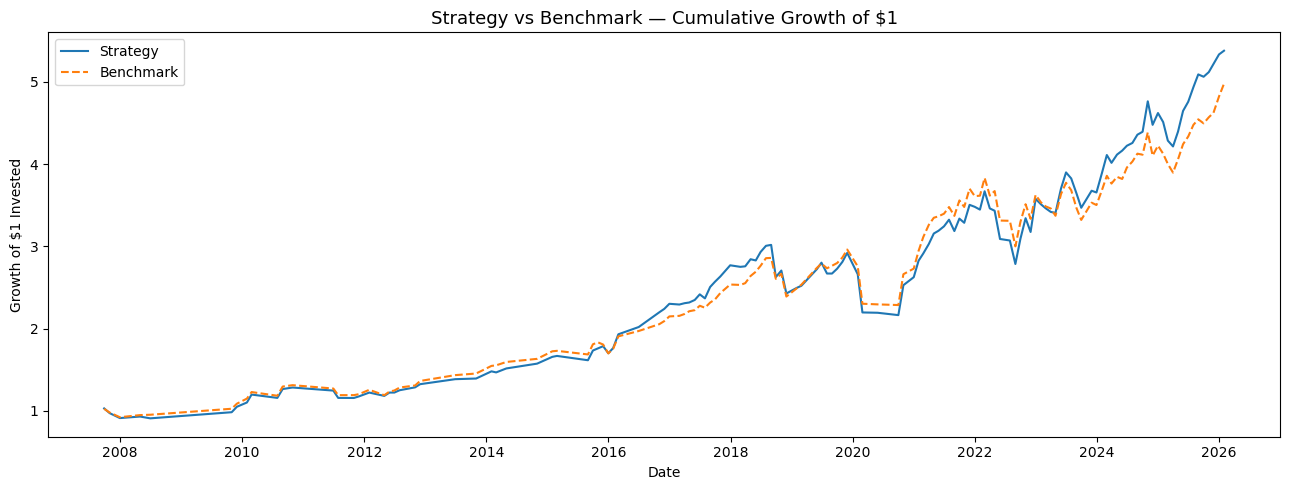

Metric                        Strategy    Benchmark
--------------------------------------------------
Cumulative Return              437.87%      397.78%
Sharpe Ratio                    0.9606       0.9847
Max Drawdown                   -28.31%      -22.79%


In [61]:

# Get trading days timeline
rebalance_dates_df = (
    df.groupby([df['date'].dt.year, df['date'].dt.month])['date']
      .max()
      .reset_index(drop=True)
      .to_frame(name='date')
)

# Get top sectors and fwd returns per date
sectors_filt = (
    df.merge(rebalance_dates_df, on='date', how='inner')
      .groupby(['date', 'sector'], as_index=False)
      .agg(fwd_ret_21d=('fwd_ret_21d', 'mean'))
      .sort_values('date')
)

sectors_filt = sectors_filt.merge(
    market[['date', 'combined_regime']],
    on='date',
    how='left'
)

def get_top_sectors_using_history(historical_sector_perf, regime, top_n=3): # this function uses only historical data up to the current date

        top_sectors = (
            historical_sector_perf[(historical_sector_perf['combined_regime'] == regime) & (historical_sector_perf['obs'] >= 30)] # only consider sectors with at least 30 observations in that regime to ensure statistical significance
            .sort_values('avg_fwd_ret_21d', ascending=False)
            .head(top_n)
            .reset_index(drop=True)
        )
        return top_sectors

# Calculate strategy returns by applying the n top sectors for each regime to the historical data and compare to benchmark (equal weight of all sectors)
def get_backtest_df_per_n_top_sectors(n_sectors=3):
    results = []
    for date in rebalance_dates_df['date']:

        history = sectors_filt[sectors_filt['date'] < date]

        if history['date'].nunique() < 12: # skip the first year since we don't have enough data to determine the top sectors for each regime
            continue

        regime = sectors_filt[sectors_filt['date'] == date]['combined_regime'].values[0]
        historical_sector_perf = history.groupby(['combined_regime', 'sector'], as_index=False).agg(avg_fwd_ret_21d=('fwd_ret_21d', 'mean'), obs = ('fwd_ret_21d', 'count'))
        top_sectors = get_top_sectors_using_history(historical_sector_perf, regime, n_sectors)[['sector', 'avg_fwd_ret_21d']] # get n top sectors

        if top_sectors.empty:
            continue

        sectors_realized_ret = sectors_filt[(sectors_filt['sector'].isin(top_sectors['sector'])) & (sectors_filt['date'] == date)][['sector', 'fwd_ret_21d']].sort_values('sector')

        if sectors_realized_ret.empty:
            continue

        strategy_return = sectors_realized_ret['fwd_ret_21d'].mean() # equal weight return of the 3 sectors
        benchmark_return = sectors_filt[sectors_filt['date'] == date]['fwd_ret_21d'].mean() # average return across all sectors as benchmark

        results.append({
            'date': date,
            'regime': regime,
            'strategy_return': strategy_return,
            'benchmark_return': benchmark_return
        })

    backtest_df = pd.DataFrame(results)
    backtest_df = backtest_df.dropna(subset=['strategy_return', 'benchmark_return']).copy()
    backtest_df = backtest_df.sort_values('date').reset_index(drop=True)

    return backtest_df


def plot_backtest_window(backtest_df, start, end=None):

    end = end or pd.Timestamp.today().strftime('%Y-%m-%d')

    zoom = backtest_df[
        (backtest_df['date'] >= start) &
        (backtest_df['date'] <= end)
    ].copy()

    if zoom.empty:
        print(f"No data found between {start} and {end}")
        return
    
    zoom['strategy_growth']  = (1 + zoom['strategy_return']).cumprod()
    zoom['benchmark_growth'] = (1 + zoom['benchmark_return']).cumprod()

    # Compute metrics
    zoom_cum_ret_str   = zoom['strategy_growth'].iloc[-1]  - 1
    zoom_cum_ret_bench = zoom['benchmark_growth'].iloc[-1] - 1
    zoom_sharpe_str    = (zoom['strategy_return'].mean()  / zoom['strategy_return'].std())  * np.sqrt(12)
    zoom_sharpe_bench  = (zoom['benchmark_return'].mean() / zoom['benchmark_return'].std()) * np.sqrt(12)
    zoom_dd_str        = (zoom['strategy_growth']  / zoom['strategy_growth'].cummax()  - 1).min()
    zoom_dd_bench      = (zoom['benchmark_growth'] / zoom['benchmark_growth'].cummax() - 1).min()

    # Strategy vs benchmark growth chart WINDOW
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(zoom['date'], zoom['strategy_growth'],  label='Strategy',  linewidth=1.5)
    ax.plot(zoom['date'], zoom['benchmark_growth'], label='Benchmark', linewidth=1.5, linestyle='--')
    ax.set_title(f'Strategy vs Benchmark — {start} to {end}', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Growth of $1 Invested')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Summary metrics for zoom window
    print(f"Period: {start} → {end}")
    print()
    print(f"{'Metric':<25} {'Strategy':>12} {'Benchmark':>12}")
    print("-" * 50)
    print(f"{'Cumulative Return':<25} {zoom_cum_ret_str:>12.2%} {zoom_cum_ret_bench:>12.2%}")
    print(f"{'Sharpe Ratio':<25} {zoom_sharpe_str:>12.4f} {zoom_sharpe_bench:>12.4f}")
    print(f"{'Max Drawdown':<25} {zoom_dd_str:>12.2%} {zoom_dd_bench:>12.2%}")

def plot_backtest(backtest_df):

    backtest_df = backtest_df.copy()

    # Convert 21d forward returns into growth curves
    backtest_df['strategy_growth'] = (1 + backtest_df['strategy_return']).cumprod()
    backtest_df['benchmark_growth'] = (1 + backtest_df['benchmark_return']).cumprod()

    # Add sharpe-like ratio of the strategy
    mean_strategy_return = backtest_df['strategy_return'].mean()
    std_strategy_return = backtest_df['strategy_return'].std()
    strategy_sharpe = (mean_strategy_return / std_strategy_return) * np.sqrt(12)
    # Add sharpe-like ratio of the benchmark
    mean_benchmark_return = backtest_df['benchmark_return'].mean()
    std_benchmark_return = backtest_df['benchmark_return'].std()
    benchmark_sharpe = (mean_benchmark_return / std_benchmark_return) * np.sqrt(12)

    # Max drawdown
    peak = backtest_df['strategy_growth'].cummax()
    drawdown_series = backtest_df['strategy_growth'] / peak - 1
    max_drawdown_str = drawdown_series.min()
    # Max drawdown benchmark
    max_drawdown_benchk = (backtest_df['benchmark_growth'] / backtest_df['benchmark_growth'].cummax() - 1).min()

    # Cumulative return strategy
    cumm_return_str = backtest_df['strategy_growth'].iloc[-1] - 1
    # Cumulative return benchmark
    cumm_return_benchk = backtest_df['benchmark_growth'].iloc[-1] - 1


    # Strategy vs benchmark growth chart ALL TIME
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(backtest_df['date'], backtest_df['strategy_growth'],  label='Strategy',  linewidth=1.5)
    ax.plot(backtest_df['date'], backtest_df['benchmark_growth'], label='Benchmark', linewidth=1.5, linestyle='--')
    ax.set_title('Strategy vs Benchmark — Cumulative Growth of $1', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Growth of $1 Invested')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Summary metrics
    print(f"{'Metric':<25} {'Strategy':>12} {'Benchmark':>12}")
    print("-" * 50)
    print(f"{'Cumulative Return':<25} {cumm_return_str:>12.2%} {cumm_return_benchk:>12.2%}")
    print(f"{'Sharpe Ratio':<25} {strategy_sharpe:>12.4f} {benchmark_sharpe:>12.4f}")
    print(f"{'Max Drawdown':<25} {max_drawdown_str:>12.2%} {max_drawdown_benchk:>12.2%}")

backtest_df = get_backtest_df_per_n_top_sectors(n_sectors = 5) # n_sectors determines how many top sectors to invest in

# Example views
plot_backtest_window(backtest_df, '2025-01-01')
plot_backtest_window(backtest_df, '2008-01-01', '2009-12-31') # 2008 crisis
plot_backtest_window(backtest_df, '2020-01-01', '2021-12-31') # COVID

# All time graph
plot_backtest(backtest_df)

## Summary

This notebook built a regime-aware sector rotation model from 25 years of S&P 500 data.

| Step | Output |
|------|--------|
| Feature engineering | 15+ per-stock technical indicators |
| Market aggregation | Daily market-wide return, volatility, and breadth signals |
| Regime classification | 9 combined regimes (trend × volatility) |
| Sector analysis | Historical return, hit rate, and Sharpe-like ratio per regime |
| Recommendation | Top 3 sectors for the current regime |
| Backtest | Strategy vs equal-weight benchmark with Sharpe and max drawdown |